# From inventory flow to a validated simulation

Reuse the small daily tea scenario from Notebook 01, then let `SimulationEngine` own the complete run: demand validation, copied state, timing, canonical event rows, and reproducibility evidence.

Why simulate: backtest a policy on one fixed demand path and read what it would have served, ordered, and held from the event ledger. This notebook runs one policy; Notebook 06 compares two on identical demand; Notebook 10 takes the same calls into a daily close.


## 1. Build one complete, explicit scenario

The demand path is seeded and mechanical. Opening stock, lead time, review period, shortage mode, windows, and the demand-source name are all declared rather than inferred. This is a teaching scenario: Stockcast accounts for its inventory consequences; it does not claim that these assumptions describe a real tea operation.

The engine will make an opening decision before the first demand row, then score the middle 16 days. Four warm-up days establish the run state, and eight settlement days show tail demand while new settlement orders remain disabled.

In [2]:
# Section 1: tools to generate the demand path and plot it.
import matplotlib.pyplot as plt
import pandas as pd

from stockcast.utils import DemandGenerator


In [3]:
# Shared coordinates and policy timing for this one-SKU daily scenario.
sku = 'tea_250g'

# This is the state date before the first demand period.
opening_date = pd.Timestamp('2026-01-05')

# Stockcast needs an explicit forward frequency for both demand and state updates.
period_frequency = 'D'

# Orders take two days to arrive; stock is reviewed every four days.
lead_time = 2
review_period = 4

# Fixed seed keeps the synthetic teaching path reproducible.
random_seed = 7


### Generate and inspect the demand calendar

This cell makes the same 28-day seeded path used in Notebook 01. The first demand date is one day after the declared opening state.

In [4]:
# Create the same 28-day seeded path used in Notebook 01.
# Demand period 0 occurs on the day after the opening state.
demand = DemandGenerator(
    [sku],
    start_date=opening_date + pd.Timedelta(days=1),
    period_frequency=period_frequency,
    seed=random_seed,
).seasonal(n_periods=28, base=5.0, amplitude=1.5, season_length=7, std=0.35)

demand.head(7)


,unique_id,y,period,date
0,tea_250g,5.000431,0,2026-01-06
1,tea_250g,6.277308,1,2026-01-07
2,tea_250g,6.366444,2,2026-01-08
3,tea_250g,5.339118,3,2026-01-09
4,tea_250g,4.190040,4,2026-01-10
5,tea_250g,3.190532,5,2026-01-11
6,tea_250g,3.848303,6,2026-01-12


### See the demand before inventory decisions

This is the only input the simulator will consume as demand. The line makes the four seven-day demand cycles visible before orders or receipts affect inventory.

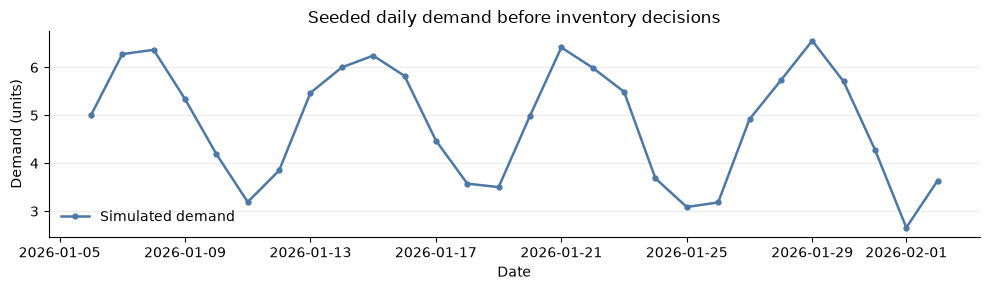

In [5]:
# Plot the complete generated path before inventory decisions change the state.
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(demand['date'], demand['y'], color='#4C78A8', marker='o',
        markersize=3.5, linewidth=1.8, label='Simulated demand')
ax.set(title='Seeded daily demand before inventory decisions', xlabel='Date', ylabel='Demand (units)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


### Declare the opening state and run windows

Opening on-hand stock is an observed scenario input, not an estimate from demand. The settings table makes the engine timing visible before the run.

In [6]:
# Opening stock is a declared scenario input, not an estimate from the demand path.
opening_stock = pd.DataFrame({'unique_id': [sku], 'observed_on_hand': [40.0]})
opening_stock


,unique_id,observed_on_hand
0,tea_250g,40.0


In [7]:
# Section 1 continued: state holder for on-hand, pipeline, and backlog.
from stockcast import InventoryStateDataFrame

# The maximum lead time sets the length of the state pipeline array.
inventory = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False
).initialize_from_observed(
    opening_stock, on_hand_column='observed_on_hand', start_date=opening_date
)
inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=40, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [8]:
# Four warm-up days, sixteen scoring days, and eight settlement days.
# Settlement shows tail demand while new settlement orders stay disabled.
scenario = pd.DataFrame([{
    'SKU': sku, 'opening_on_hand': 40.0, 'lead_time_days': lead_time,
    'review_period_days': review_period, 'initial_decision': 'none',
    'warmup_days': 4, 'scoring_days': 16, 'settlement_days': 8,
    'order_during_settlement': False, 'demand_source_name': 'seeded_tea_tutorial',
    'random_seed': random_seed,
}])
print('Scenario settings')
print(scenario.to_string(index=False))
print('\nExplicit opening state')
print(inventory.get_dataframe()[['unique_id', 'on_hand', 'backorders', 'in_transit', 'period', 'date']].to_string(index=False))


Scenario settings
     SKU  opening_on_hand  lead_time_days  review_period_days initial_decision  warmup_days  scoring_days  settlement_days  order_during_settlement  demand_source_name  random_seed
tea_250g             40.0               2                   4             none            4            16                8                    False seeded_tea_tutorial            7

Explicit opening state
unique_id  on_hand  backorders in_transit  period       date
 tea_250g     40.0         0.0 [0.0, 0.0]     0.0 2026-01-05


## 2. Give the policy a dated protection target

The `(R, S)` policy still needs an externally calculated cumulative target for its six-day protection horizon. The 42-unit value is the same declared target used in Notebook 01. Here its forecast origin is the opening decision date, so its end date is six days later. Stockcast validates this timing and provenance; it does not fit or invent the target.

In [9]:
# One direct cumulative target per SKU for the six-day protection horizon.
target = pd.DataFrame({
    'unique_id': [sku],
    'protection_target': [42.0],
    'target_end_date': [opening_date + pd.Timedelta(days=lead_time + review_period)],
})
target


,unique_id,protection_target,target_end_date
0,tea_250g,42.0,2026-01-11


### Fit the policy from that target

The policy checks the target's probability, horizon, origin, frequency, and end date before it can request an order.

In [10]:
# Section 2: order-up-to policy and its protection target.
from stockcast import OrderUpToPolicy

policy = OrderUpToPolicy(
    lead_time=lead_time,  # 2-day delivery delay; order enters pipeline, not on-hand.
    review_period=review_period,  # Review every 4 days; only those periods may order.
    service_level=0.95,  # Declared 95% protection; must match target_probability below.
    allow_backorders=False,  # Lost sales; matches the opening state, unmet demand is lost.
).fit(
    target,  # One externally calculated cumulative target row for this SKU.
    target_column='protection_target',  # S value column: 42 units for the 6-day horizon.
    target_probability=0.95,  # Probability the target represents; fail-closed match to service_level.
    protection_horizon=lead_time + review_period,  # H = 2 + 4 = 6 days of demand to cover.
    target_source='external_direct',  # Asserts S was computed outside Stockcast; no aggregation.
    forecast_origin=opening_date,  # Info date of the opening decision; anchors end-date check.
    forecast_frequency=period_frequency,  # Daily steps; must match demand and state frequency.
    target_end_date_column='target_end_date',  # Must equal origin + H (2026-01-11); validated.
)

print('Fitted target')
print(policy.get_target_levels().to_string(index=False))
print('\nTarget metadata')
print(pd.DataFrame([policy.get_target_metadata()]).to_string(index=False))

assert policy.get_target_levels().loc[0, 'target_level'] == 42.0


Fitted target
unique_id  target_level
 tea_250g          42.0

Target metadata
                 representation  target_probability  protection_horizon   target_source     forecast_origin forecast_frequency     target_end_date
direct_protection_period_target                0.95                   6 external_direct 2026-01-05T00:00:00                  D 2026-01-11T00:00:00


The default periodic schedule first decides before demand period 0. `initial_decision="none"` is the neutral compatibility argument; schedules control eligibility. Every demand row advances state, while settlement suppresses new decisions unless explicitly enabled.


In [11]:
# Section 3: engine owns timing, copied state, events, and manifest.
from stockcast import SimulationEngine

# The engine receives all timing and provenance inputs explicitly.
engine = SimulationEngine()
result = engine.run(
    policy=policy,  # Fitted (R,S) policy; engine deep-copies it, caller object stays unchanged.
    demand_source=demand,  # Complete 28-row demand calendar; consumed in every window.
    inventory=inventory,  # Explicit opening state at 2026-01-05; also deep-copied.
    n_periods=28,  # Total demand rows to simulate; must equal warmup + scoring + settlement.
    period_frequency=period_frequency,  # 'D': one engine step per demand date, forward only.
    initial_decision='none',  # First-period eligibility comes from the policy schedule.
    warmup_periods=4,  # Establish run state; advances demand but excluded from scoring.
    scoring_periods=16,  # Middle segment feeding summary() and evaluation below.
    settlement_periods=8,  # Tail demand shown with new review orders disabled here.
    order_during_settlement=False,  # Settlement still advances demand, but suppresses new orders.
    demand_source_name='seeded_tea_tutorial',  # Non-empty provenance label kept in the manifest.
    random_seed=random_seed,  # Seed 7 for the synthetic demand path; explicit None if no randomness.
)


### Read the resulting state and scoring summary

These outputs come from the engine-owned run. `summary()` deliberately uses scoring events only.

In [12]:
# The engine owns this state; the caller-owned `inventory` above is unchanged.
result.inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=0, total_safety_stock=0, total_backorders=0, has_stockout=True, has_backorder=False)

In [13]:
print('Final state')
print(result.inventory.inventory_position()[[
    'unique_id', 'on_hand', 'backorders', 'total_in_transit',
    'inventory_position', 'period', 'date'
]].to_string(index=False))
print('\nScoring summary')
print(pd.DataFrame([result.summary()]).round(3).to_string(index=False))


Final state
unique_id  on_hand  backorders  total_in_transit  inventory_position  period       date
 tea_250g      0.0         0.0               0.0                 0.0    28.0 2026-02-02

Scoring summary
 fill_rate  demand_period_service_level  mean_ending_on_hand_per_sku_period  stockout_periods  total_order_units  order_event_count  sku_order_line_count
       1.0                          1.0                              20.009                 0             80.705                  4                     4


### See which days are warm-up, scoring, and settlement

The engine consumes demand in every window. The coloured bands show why only the middle segment supplies the summary and evaluation, while settlement still reveals the tail of earlier orders.

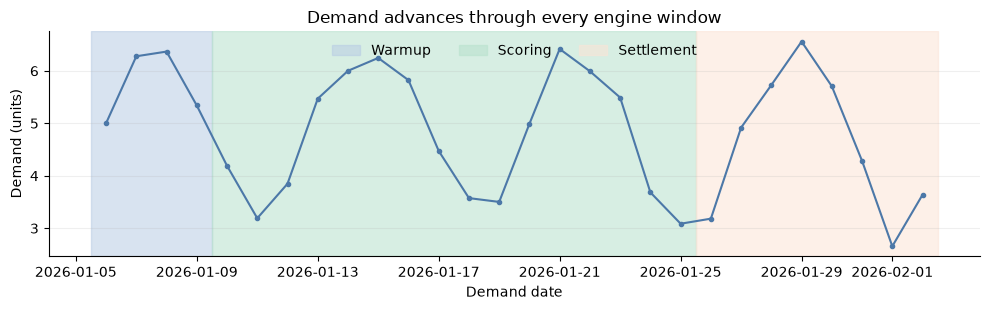

In [14]:
window_colors = {'warmup': '#B8CCE4', 'scoring': '#B7E1CD', 'settlement': '#FCE4D6'}
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(demand['date'], demand['y'], color='#4C78A8', marker='o', markersize=3, linewidth=1.5, zorder=2)
for window, rows in result.to_event_frame(window='all').query("event_type == 'period'").groupby('run_window', sort=False):
    ax.axvspan(rows['date'].min() - pd.Timedelta(hours=12), rows['date'].max() + pd.Timedelta(hours=12),
               color=window_colors[window], alpha=0.55, label=window.title(), zorder=0)
ax.set(title='Demand advances through every engine window', xlabel='Demand date', ylabel='Demand (units)')
ax.legend(frameon=False, ncol=3, loc='upper center')
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## 4. Inspect the canonical event ledger

The ledger is the accounting evidence for the run. It includes the first decision in an ordinary demand period and records each period's demand, receipt, fulfillment, shortage, order, and ending state. The scoring slice below is what `summary()` uses; the complete ledger also retains warm-up and settlement transitions.

In [15]:
event_columns = [
    'event_type', 'run_window', 'period', 'date', 'demand', 'received_units',
    'fulfilled_units', 'shortage_units', 'order_quantity',
    'ending_on_hand', 'on_order_end', 'inventory_position_end',
]
scoring_events = result.to_event_frame(window='scoring')
all_events = result.to_event_frame(window='all')
# Period rows exclude the separate opening-decision event for time-series plots.
period_events = all_events.loc[all_events['event_type'] == 'period'].copy()

print('Ledger size by view')
print(f"scoring period rows: {len(scoring_events)}")
print(f"all events: {len(all_events)} (period rows: {len(period_events)})")
print('\nOpening decision')
print(all_events.loc[all_events['event_type'] != 'period', event_columns].round(2).to_string(index=False))


Ledger size by view
scoring period rows: 16
all events: 28 (period rows: 28)

Opening decision
Empty DataFrame
Columns: [event_type, run_window, period, date, demand, received_units, fulfilled_units, shortage_units, order_quantity, ending_on_hand, on_order_end, inventory_position_end]
Index: []


/tmp/ipykernel_1167758/539494627.py:15: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(all_events.loc[all_events['event_type'] != 'period', event_columns].round(2).to_string(index=False))


### Inspect the scoring rows

These are the 16 rows that contribute to the default summary and the evaluation below.

In [16]:
print('Selected scoring events (first eight)')
print(scoring_events[event_columns].head(8).round(2).to_string(index=False))

print('\nScoring order events')
scoring_orders = scoring_events.loc[scoring_events['order_quantity'] > 0, event_columns]
print(scoring_orders.round(2).to_string(index=False))

assert set(scoring_events['run_window']) == {'scoring'}
assert len(scoring_events) == 16


Selected scoring events (first eight)
event_type run_window  period       date  demand  received_units  fulfilled_units  shortage_units  order_quantity  ending_on_hand  on_order_end  inventory_position_end
    period    scoring     5.0 2026-01-10    4.19            0.00             4.19             0.0           22.98           14.83         22.98                   37.81
    period    scoring     6.0 2026-01-11    3.19            0.00             3.19             0.0            0.00           11.64         22.98                   34.62
    period    scoring     7.0 2026-01-12    3.85           22.98             3.85             0.0            0.00           30.77          0.00                   30.77
    period    scoring     8.0 2026-01-13    5.47            0.00             5.47             0.0            0.00           25.30          0.00                   25.30
    period    scoring     9.0 2026-01-14    6.00            0.00             6.00             0.0           16.70         

/tmp/ipykernel_1167758/2781060299.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(scoring_events[event_columns].head(8).round(2).to_string(index=False))
/tmp/ipykernel_1167758/2781060299.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(scoring_orders.round(2).to_string(index=False))


### Inspect the complete run evidence

The full ledger retains all orders and demand transitions outside scoring, so its demand total must still match the original calendar.

In [17]:
print('Run evidence: opening decision and first demand periods')
print(all_events[event_columns].head(5).round(2).to_string(index=False))

print('\nRun evidence: settlement tail')
print(all_events[event_columns].tail(8).round(2).to_string(index=False))

assert set(all_events.loc[all_events['event_type'] == 'period', 'run_window']) == {
    'warmup', 'scoring', 'settlement'
}
assert all_events.loc[all_events['event_type'] == 'period', 'demand'].sum() == demand['y'].sum()


Run evidence: opening decision and first demand periods
event_type run_window  period       date  demand  received_units  fulfilled_units  shortage_units  order_quantity  ending_on_hand  on_order_end  inventory_position_end
    period     warmup     1.0 2026-01-06    5.00             0.0             5.00             0.0            2.00           35.00          2.00                   37.00
    period     warmup     2.0 2026-01-07    6.28             0.0             6.28             0.0            0.00           28.72          2.00                   30.72
    period     warmup     3.0 2026-01-08    6.37             2.0             6.37             0.0            0.00           24.36          0.00                   24.36
    period     warmup     4.0 2026-01-09    5.34             0.0             5.34             0.0            0.00           19.02          0.00                   19.02
    period    scoring     5.0 2026-01-10    4.19             0.0             4.19             0.0       

/tmp/ipykernel_1167758/1840564777.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(all_events[event_columns].head(5).round(2).to_string(index=False))
/tmp/ipykernel_1167758/1840564777.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(all_events[event_columns].tail(8).round(2).to_string(index=False))


### Read demand, decisions, receipts, and state together

This ledger-derived figure links the components in one direction: demand reduces stock; an order raises inventory position and pipeline immediately; the receipt marker appears later, on the end-of-day stock after that day's demand is served.

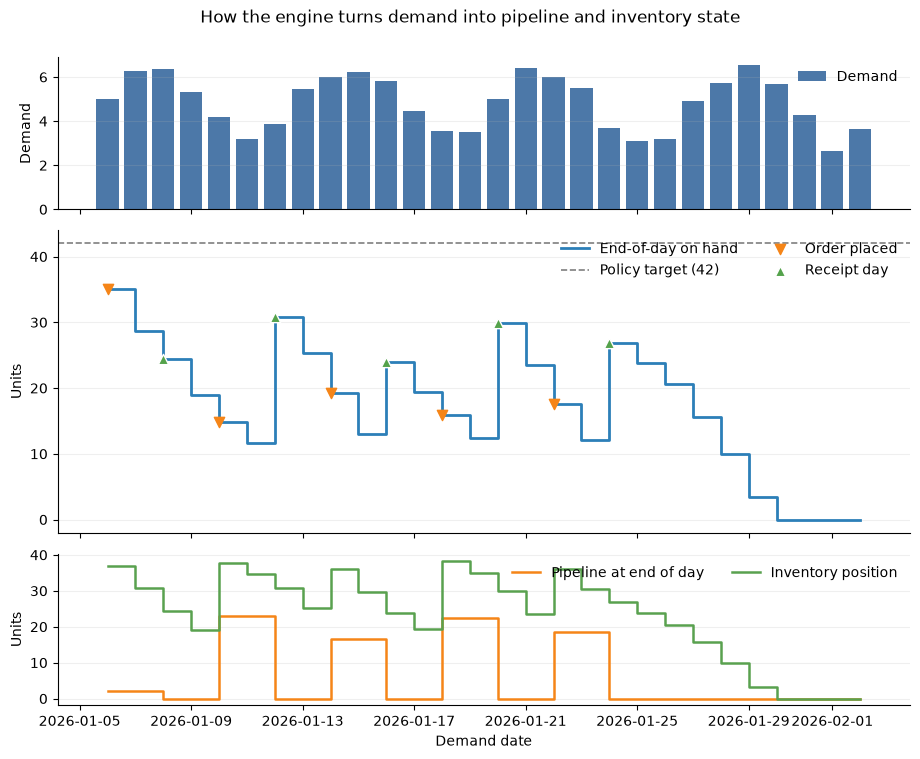

In [18]:
order_events = period_events.loc[period_events['order_quantity'] > 0]
receipt_events = period_events.loc[period_events['received_units'] > 0]
target_level = float(policy.get_target_levels().loc[0, 'target_level'])

fig, (demand_ax, stock_ax, position_ax) = plt.subplots(
    3, 1, figsize=(11, 8), sharex=True, gridspec_kw={'height_ratios': [1, 2, 1], 'hspace': 0.1}
)
# Demand is kept on its own scale so it does not hide the state trajectory.
demand_ax.bar(period_events['date'], period_events['demand'], width=0.8, color='#4C78A8', label='Demand')
demand_ax.set_ylabel('Demand')
demand_ax.legend(frameon=False, loc='upper right')

stock_ax.step(period_events['date'], period_events['ending_on_hand'], where='post', color='#2C7FB8', linewidth=2, label='End-of-day on hand')
stock_ax.axhline(target_level, color='#7F7F7F', linestyle='--', linewidth=1.2, label='Policy target (42)')
stock_ax.scatter(order_events['date'], order_events['ending_on_hand'], marker='v', s=55, color='#F58518', zorder=4, label='Order placed')
stock_ax.scatter(receipt_events['date'], receipt_events['ending_on_hand'], marker='^', s=55, color='#54A24B', edgecolor='white', zorder=5, label='Receipt day')
stock_ax.set_ylabel('Units')
stock_ax.legend(frameon=False, ncol=2, loc='upper right')

position_ax.step(period_events['date'], period_events['on_order_end'], where='post', color='#F58518', linewidth=1.8, label='Pipeline at end of day')
position_ax.step(period_events['date'], period_events['inventory_position_end'], where='post', color='#59A14F', linewidth=1.8, label='Inventory position')
position_ax.set(xlabel='Demand date', ylabel='Units')
position_ax.legend(frameon=False, ncol=2, loc='upper right')

for axis in (demand_ax, stock_ax, position_ax):
    axis.grid(axis='y', alpha=0.2)
    axis.spines[['top', 'right']].set_visible(False)
fig.suptitle('How the engine turns demand into pipeline and inventory state', y=0.98)
fig.subplots_adjust(top=0.92)
plt.show()


## 5. Keep the settings beside the results

A summary is useful, but it cannot reproduce the scenario alone. The run manifest preserves the demand fingerprint and generation settings, the target metadata, opening-state fingerprint, timing windows, and dependency/source provenance. The selected fields below make those choices inspectable without turning this notebook into a manifest dump.

In [19]:
manifest = result.run_manifest
manifest_view = pd.DataFrame([{
    'demand_source_name': manifest['demand_source']['name'],
    'demand_rows': manifest['demand_source']['rows'],
    'demand_seed': manifest['demand_source']['random_seed'],
    'period_frequency': manifest['run_settings']['period_frequency'],
    'initial_decision': manifest['run_settings']['initial_decision'],
    'warmup_periods': manifest['run_settings']['warmup_periods'],
    'scoring_periods': manifest['run_settings']['scoring_periods'],
    'settlement_periods': manifest['run_settings']['settlement_periods'],
    'order_during_settlement': manifest['run_settings']['order_during_settlement'],
}])
print('Selected run-manifest settings')
print(manifest_view.to_string(index=False))
print('\nPolicy target metadata retained in the manifest')
print(pd.DataFrame([manifest['policy']['target_metadata']]).to_string(index=False))


Selected run-manifest settings
 demand_source_name  demand_rows  demand_seed period_frequency initial_decision  warmup_periods  scoring_periods  settlement_periods  order_during_settlement
seeded_tea_tutorial           28            7                D             none               4               16                   8                    False

Policy target metadata retained in the manifest
                 representation  target_probability  protection_horizon   target_source     forecast_origin forecast_frequency     target_end_date
direct_protection_period_target                0.95                   6 external_direct 2026-01-05T00:00:00                  D 2026-01-11T00:00:00


## 6. Evaluate the scoring window explicitly

`InventoryEvaluator` consumes validated event rows, not policy internals or the plot. We select the scoring window and request one pooled result with `groupby=[]`. These are units and service measures only, so no cost component or rate is implied by this synthetic scenario.

In [20]:
# Section 6: scoring-window evaluation from validated events, not plots.
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, demand_period_service_level, fill_rate,
    order_event_count, order_units,
)

metrics = InventoryEvaluator().fit(
    simulation_result=result, window='scoring'
).evaluate(
    metrics=[
        fill_rate,
        demand_period_service_level,
        avg_on_hand,
        order_units,
        order_event_count,
    ],
    groupby=[],
)
print(metrics.round(3).to_string(index=False))


 fill_rate  demand_period_service_level  avg_on_hand  order_units  order_event_count
       1.0                          1.0       20.009       80.705                  4


## 7. Use the plot to read the run, not to replace the ledger

The chart gives a compact view of the engine-owned end-of-day stock trajectory. Demand and receipts are already accounted for in the event rows above; the visual is presentation evidence only. Here, a shaded band denotes a stockout day, while the line remains end-of-day on-hand stock.

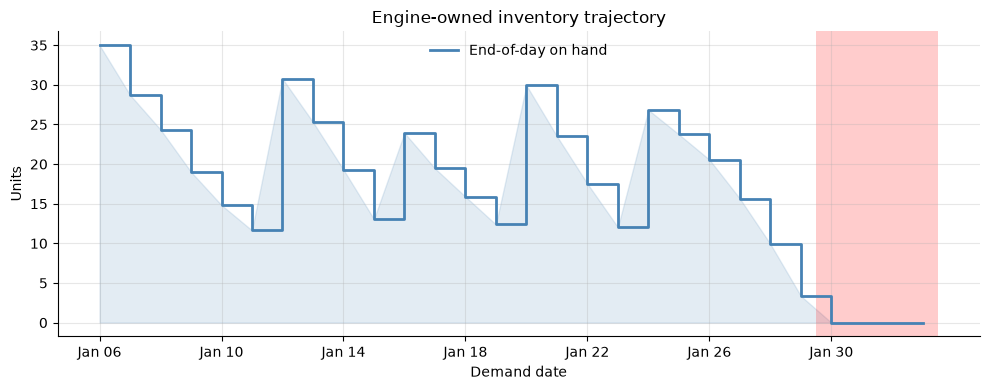

In [21]:
# Section 7: presentation plot of the engine-owned trajectory; ledger stays the evidence.
from stockcast.visualization import plot_inventory

fig, ax = plt.subplots(figsize=(10, 4))
plot_inventory(result, sku=sku, ax=ax)
period_events = all_events.loc[all_events['event_type'] == 'period'].copy()
ax.lines[0].set(drawstyle='steps-post', linewidth=2.0, label='End-of-day on hand')
tick_events = period_events.iloc[::4]
ax.set_xticks(tick_events['period'])
ax.set_xticklabels(tick_events['date'].dt.strftime('%b %d'))
ax.set(
    title='Engine-owned inventory trajectory',
    xlabel='Demand date',
    ylabel='Units',
)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()
